## PHASE 1: DATA COLLECTION

In [2]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

## PHASE 2: DATA PREPROCESSING

### 1. Check for Missing Values in Breast Cancer Dataset

In [3]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

### 2. Standardize Features for Breast Cancer Dataset (StandardScaler)

In [4]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

X = df.drop(columns='target')
y = df['target']

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 3. Split Breast Cancer Dataset into Train (80%) and Test (20%)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## PHASE 3: KNN (K-NEAREST NEIGHBORS)

### 1. Build KNN Classifier for Breast Cancer Dataset

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

### 2. Find Optimal K Using Elbow Method (Error Rate vs K)

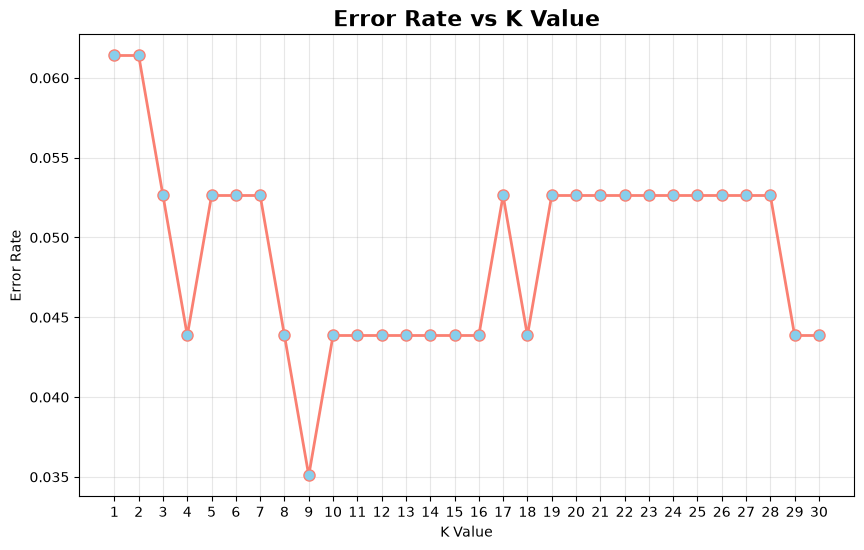

In [8]:
error_rates = []

for k in range(1, 31):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    pred_temp = knn_temp.predict(X_test)
    error_rates.append(np.mean(pred_temp != y_test))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), error_rates, color='salmon', marker='o', markerfacecolor='skyblue', markersize=8, linewidth=2)
plt.title('Error Rate vs K Value', fontsize=16, fontweight='bold')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(range(1, 31))
plt.grid(True, alpha=0.3)
plt.show()

### 4. Use Different Distance Metrics: Euclidean, Manhattan, Minkowski

In [9]:
from sklearn.model_selection import cross_val_score

cv_scores = []

for k in range(1, 31):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = cv_scores.index(max(cv_scores)) + 1
print(f"Optimal K value: {optimal_k}")

Optimal K value: 8


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [11]:
knn_euclidean = KNeighborsClassifier(n_neighbors=optimal_k, metric='euclidean')
knn_euclidean.fit(X_train, y_train)
y_pred_euclidean = knn_euclidean.predict(X_test)

knn_manhattan = KNeighborsClassifier(n_neighbors=optimal_k, metric='manhattan')
knn_manhattan.fit(X_train, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test)

knn_minkowski = KNeighborsClassifier(n_neighbors=optimal_k, metric='minkowski', p=3)
knn_minkowski.fit(X_train, y_train)
y_pred_minkowski = knn_minkowski.predict(X_test)

print("Euclidean Accuracy:", accuracy_score(y_test, y_pred_euclidean))
print("Manhattan Accuracy:", accuracy_score(y_test, y_pred_manhattan))
print("Minkowski Accuracy:", accuracy_score(y_test, y_pred_minkowski))

Euclidean Accuracy: 0.956140350877193
Manhattan Accuracy: 0.956140350877193
Minkowski Accuracy: 0.9473684210526315


### 5. Use Weighted KNN (Distance-Based Weights)

In [12]:
knn_weighted = KNeighborsClassifier(n_neighbors=optimal_k, weights='distance')
knn_weighted.fit(X_train, y_train)
y_pred_weighted = knn_weighted.predict(X_test)

### 6. Compare Unweighted vs Weighted KNN

In [13]:
knn_unweighted = KNeighborsClassifier(n_neighbors=optimal_k, weights='uniform')
knn_unweighted.fit(X_train, y_train)
y_pred_unweighted = knn_unweighted.predict(X_test)

comparison = pd.DataFrame({
    'Weighting': ['Unweighted (uniform)', 'Weighted (distance)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_unweighted),
        accuracy_score(y_test, y_pred_weighted)
    ],
    'Precision': [
        precision_score(y_test, y_pred_unweighted),
        precision_score(y_test, y_pred_weighted)
    ],
    'Recall': [
        recall_score(y_test, y_pred_unweighted),
        recall_score(y_test, y_pred_weighted)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_unweighted),
        f1_score(y_test, y_pred_weighted)
    ]
})

print(comparison)

              Weighting  Accuracy  Precision    Recall  F1-Score
0  Unweighted (uniform)  0.956140   0.971429  0.957746  0.964539
1   Weighted (distance)  0.947368   0.957746  0.957746  0.957746


### 7. Evaluate KNN on Breast Cancer Using Accuracy, Precision, Recall, F1-Score

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_knn = accuracy_score(y_test, y_pred_weighted)
precision_knn = precision_score(y_test, y_pred_weighted)
recall_knn = recall_score(y_test, y_pred_weighted)
f1_knn = f1_score(y_test, y_pred_weighted)

print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")

Accuracy: 0.9474
Precision: 0.9577
Recall: 0.9577
F1-Score: 0.9577


### 8. Plot Confusion Matrix for Breast Cancer KNN

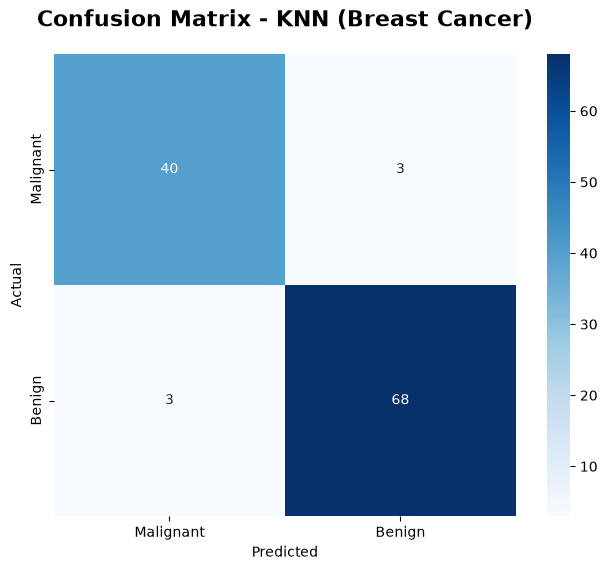

In [15]:
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_test, y_pred_weighted)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title("Confusion Matrix - KNN (Breast Cancer)", fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=42),
                            param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_

C:\Users\user1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### 9. Evaluate SVM on Breast Cancer Using All Metrics

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [18]:
y_pred_best_svm = best_svm.predict(X_test)
y_pred_proba_best_svm = best_svm.predict_proba(X_test)[:, 1]

accuracy_svm = accuracy_score(y_test, y_pred_best_svm)
precision_svm = precision_score(y_test, y_pred_best_svm)
recall_svm = recall_score(y_test, y_pred_best_svm)
f1_svm = f1_score(y_test, y_pred_best_svm)
roc_auc_svm = roc_auc_score(y_test, y_pred_proba_best_svm)

print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print(f"ROC-AUC: {roc_auc_svm:.4f}")

Accuracy: 0.9825
Precision: 0.9726
Recall: 1.0000
F1-Score: 0.9861
ROC-AUC: 0.9967


## PHASE 5: COMPARISON & OPTIMIZATION

### 1. Compare KNN vs SVM Performance on Breast Cancer Dataset

In [19]:
comparison_knn_svm = pd.DataFrame({
    'Model': ['KNN', 'SVM'],
    'Accuracy': [accuracy_knn, accuracy_svm],
    'Precision': [precision_knn, precision_svm],
    'Recall': [recall_knn, recall_svm],
    'F1-Score': [f1_knn, f1_svm]
})

print(comparison_knn_svm)

  Model  Accuracy  Precision    Recall  F1-Score
0   KNN  0.947368   0.957746  0.957746  0.957746
1   SVM  0.982456   0.972603  1.000000  0.986111


### 2. Plot Decision Boundaries for KNN (Breast Cancer - 2D after PCA)

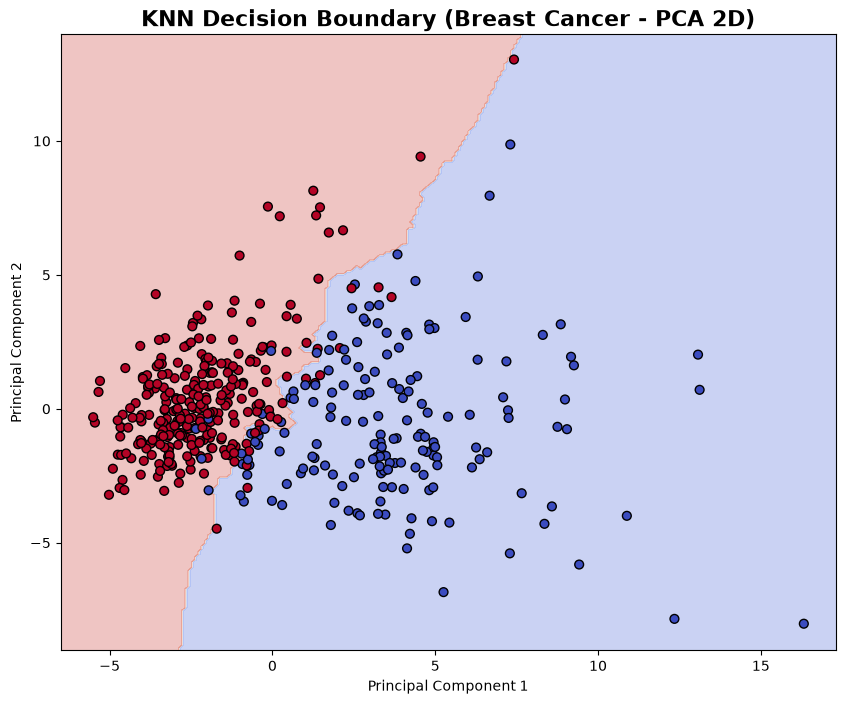

In [20]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

knn_pca = KNeighborsClassifier(n_neighbors=optimal_k)
knn_pca.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='black', s=40)
plt.title('KNN Decision Boundary (Breast Cancer - PCA 2D)', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### 3. Analyze Training Time and Prediction Time for KNN vs SVM

In [21]:
import time

# KNN timing
start_train = time.time()
knn_final = KNeighborsClassifier(n_neighbors=optimal_k, weights='distance')
knn_final.fit(X_train, y_train)
knn_train_time = time.time() - start_train

start_pred = time.time()
knn_final.predict(X_test)
knn_pred_time = time.time() - start_pred

# SVM timing
start_train = time.time()
svm_final = best_svm
svm_final.fit(X_train, y_train)
svm_train_time = time.time() - start_train

start_pred = time.time()
svm_final.predict(X_test)
svm_pred_time = time.time() - start_pred

print(f"KNN - Train Time: {knn_train_time:.4f}s, Predict Time: {knn_pred_time:.4f}s")
print(f"SVM - Train Time: {svm_train_time:.4f}s, Predict Time: {svm_pred_time:.4f}s")

KNN - Train Time: 0.0006s, Predict Time: 0.0084s
SVM - Train Time: 0.0115s, Predict Time: 0.0012s


C:\Users\user1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### 4. Create Comparison Table with All Metrics and Times

In [22]:
final_comparison = pd.DataFrame({
    'Model': ['KNN', 'SVM'],
    'Accuracy': [accuracy_knn, accuracy_svm],
    'Precision': [precision_knn, precision_svm],
    'Recall': [recall_knn, recall_svm],
    'F1-Score': [f1_knn, f1_svm],
    'Train Time (s)': [knn_train_time, svm_train_time],
    'Predict Time (s)': [knn_pred_time, svm_pred_time]
})

print(final_comparison)

  Model  Accuracy  Precision    Recall  F1-Score  Train Time (s)  \
0   KNN  0.947368   0.957746  0.957746  0.957746        0.000597   
1   SVM  0.982456   0.972603  1.000000  0.986111        0.011519   

   Predict Time (s)  
0          0.008407  
1          0.001155  
